Upload: models_catalog.csv, compute_estimates.csv, benchmark_scores.csv


Saving benchmark_scores.csv to benchmark_scores (5).csv
Saving capability_milestones.csv to capability_milestones (3).csv
Saving compute_estimates.csv to compute_estimates (4).csv
Saving models_catalog.csv to models_catalog (4).csv
Merged shape: (1276, 19)
Missing values after cleaning: 0
Target: score_pct
count    1276.000000
mean       73.359255
std        22.812458
min         3.250000
25%        60.672500
50%        79.875000
75%        92.195000
max       100.000000
Name: score_pct, dtype: float64
Train: (1020, 11) Test: (256, 11)

Linear Regression: RMSE = 21.79 | R2 = 0.1600

Decision Tree: RMSE = 7.39 | R2 = 0.9034

Random Forest: RMSE = 5.96 | R2 = 0.9372


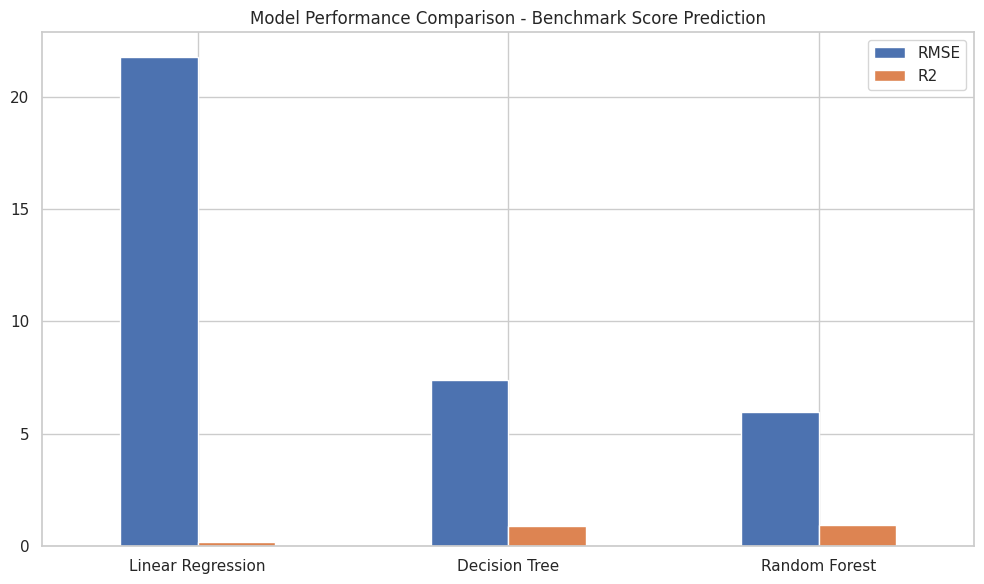

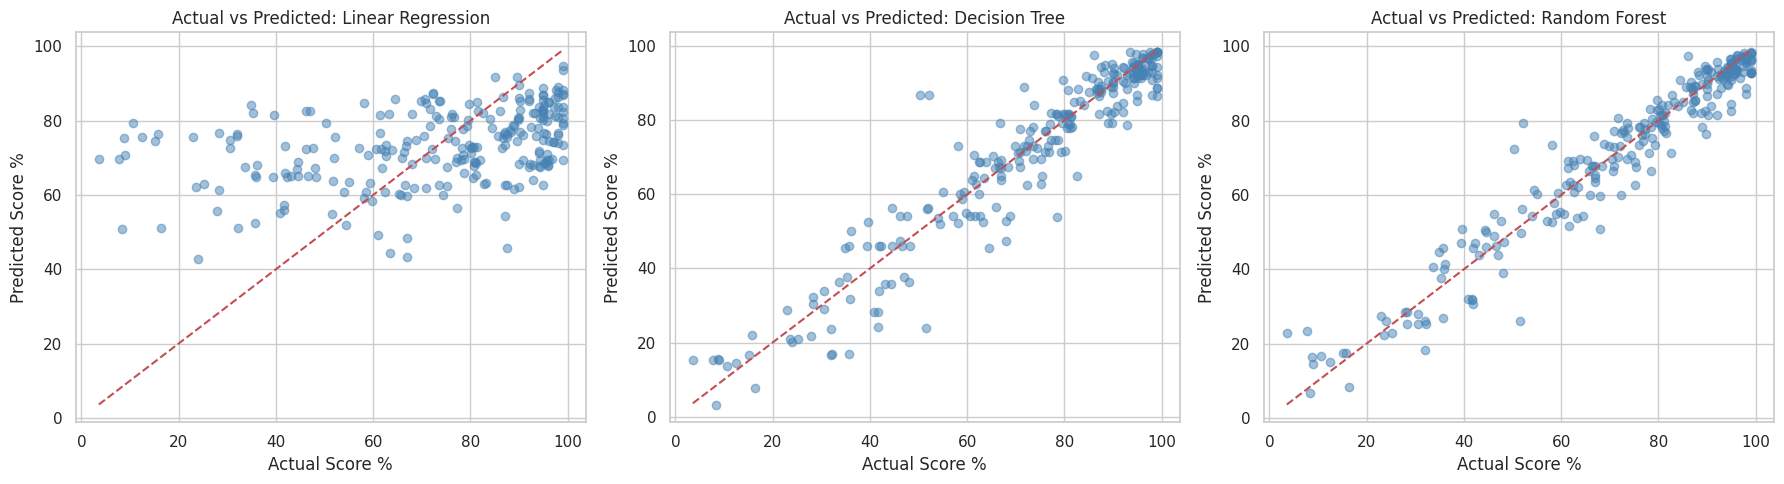

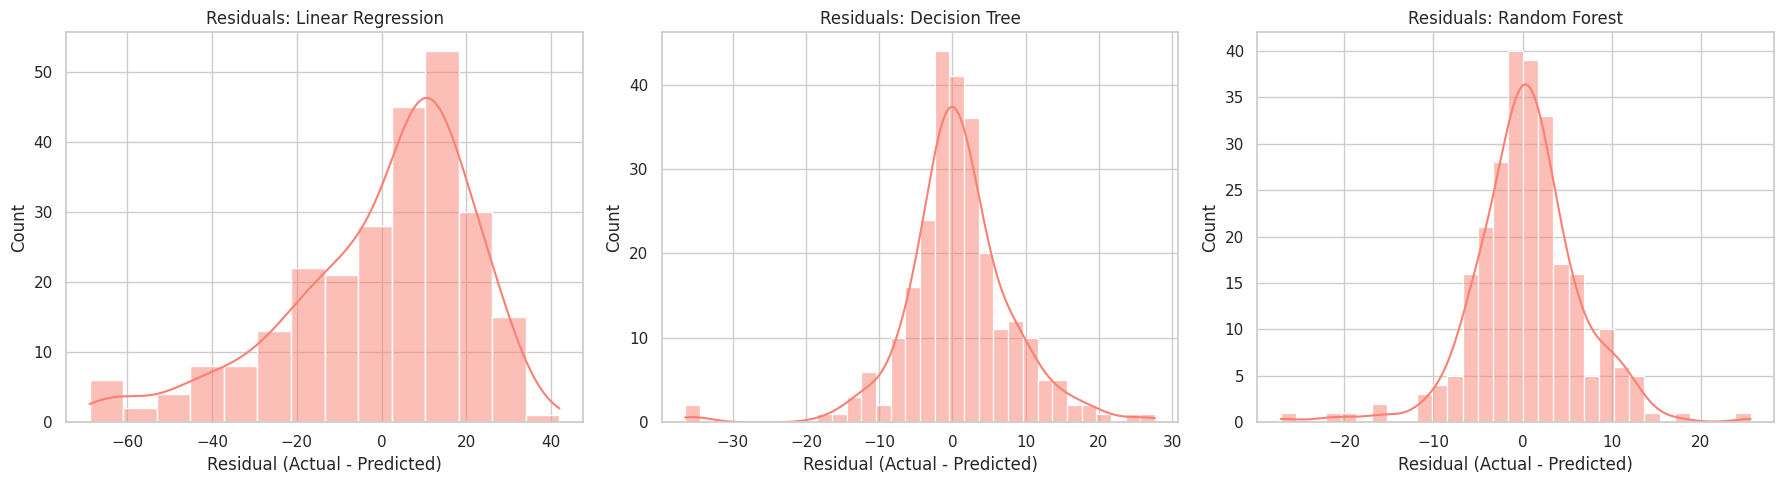

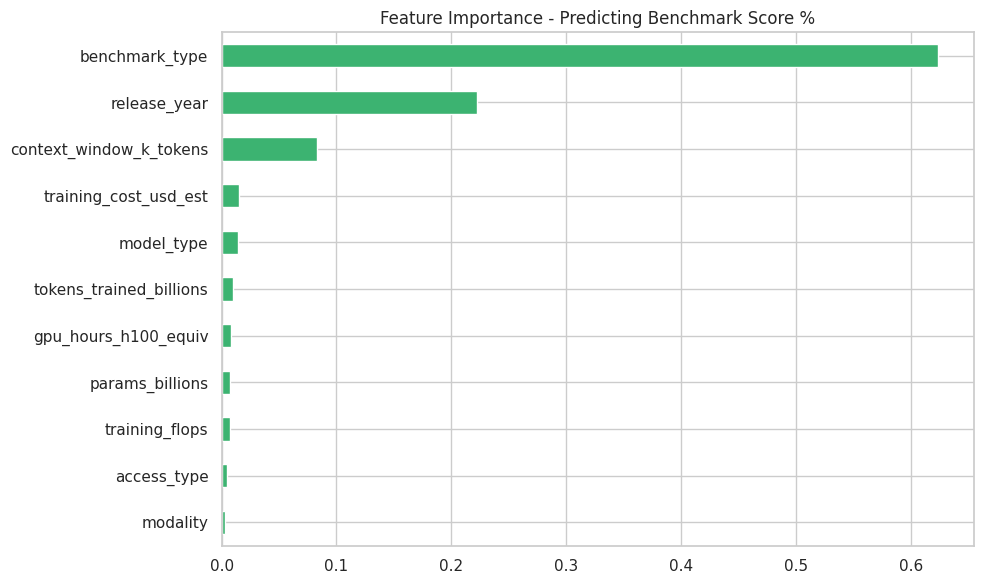

BEST MODEL: Random Forest
R2 Score: 0.9372
RMSE: 5.96

Top 5 Most Important Features:
benchmark_type             0.623868
release_year               0.222653
context_window_k_tokens    0.083115
training_cost_usd_est      0.015303
model_type                 0.013938
dtype: float64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Task 2 Complete: Benchmark score prediction model trained and evaluated.


In [6]:
# ===================================================
# TASK 2: PREDICTIVE MODELING USING MACHINE LEARNING
# Dataset: LLM Benchmarks & Capabilities
# Goal: Predict benchmark score_pct from model characteristics
# ===================================================

# %% Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 6)

# %% Step 2: Upload Files
from google.colab import files
print("Upload: models_catalog.csv, compute_estimates.csv, benchmark_scores.csv")
uploaded = files.upload()

# %% Step 3: Load & Merge Datasets
models = pd.read_csv("models_catalog.csv")
compute = pd.read_csv("compute_estimates.csv")
benchmarks = pd.read_csv("benchmark_scores.csv")

# Merge: benchmark scores + model metadata + compute info
df = benchmarks.merge(
    models[['model_id', 'release_year', 'model_type', 'access_type', 'modality', 'context_window_k_tokens', 'params_billions']],
    on='model_id', how='left'
)
df = df.merge(
    compute[['model_id', 'tokens_trained_billions', 'training_flops', 'gpu_hours_h100_equiv', 'training_cost_usd_est']],
    on='model_id', how='left'
)

print("Merged shape:", df.shape)
df.head()

# %% Step 4: Clean Data
df = df.drop_duplicates()
num_cols_check = df.select_dtypes(include=np.number).columns
for col in num_cols_check:
    df[col] = df[col].fillna(df[col].median())
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after cleaning:", df.isnull().sum().sum())

# %% Step 5: Define Target (Regression Problem)
target_col = "score_pct"   # predicting benchmark score percentage

print("Target:", target_col)
print(df[target_col].describe())

# %% Step 6: Feature Selection & Encoding
features = ['params_billions', 'release_year', 'model_type', 'access_type', 'modality',
            'context_window_k_tokens', 'tokens_trained_billions', 'training_flops',
            'gpu_hours_h100_equiv', 'training_cost_usd_est', 'benchmark_type']

df_model = df[features + [target_col]].copy()
df_model['params_billions'] = df_model['params_billions'].fillna(df_model['params_billions'].median())

cat_features = ['model_type', 'access_type', 'modality', 'benchmark_type']
for col in cat_features:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))

df_model.head()

# %% Step 7: Train-Test Split
X = df_model.drop(columns=[target_col])
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, "Test:", X_test.shape)

# %% Step 8: Train Models
models_dict = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42, max_depth=10),
    "Random Forest": RandomForestRegressor(n_estimators=150, random_state=42)
}

results = {}
for name, model in models_dict.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {"model": model, "rmse": rmse, "r2": r2, "y_pred": y_pred}
    print(f"\n{name}: RMSE = {rmse:.2f} | R2 = {r2:.4f}")

# %% Step 9: Model Comparison Chart
comp_df = pd.DataFrame({name: [res["rmse"], res["r2"]] for name, res in results.items()},
                        index=["RMSE", "R2"])
comp_df.T.plot(kind='bar', figsize=(10, 6))
plt.title("Model Performance Comparison - Benchmark Score Prediction")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=300)
plt.show()

# %% Step 10: Actual vs Predicted Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, res) in zip(axes, results.items()):
    ax.scatter(y_test, res["y_pred"], alpha=0.5, color='steelblue')
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    ax.set_title(f"Actual vs Predicted: {name}")
    ax.set_xlabel("Actual Score %")
    ax.set_ylabel("Predicted Score %")
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=300)
plt.show()

# %% Step 11: Residual Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, res) in zip(axes, results.items()):
    residuals = y_test - res["y_pred"]
    sns.histplot(residuals, kde=True, ax=ax, color='salmon')
    ax.set_title(f"Residuals: {name}")
    ax.set_xlabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.savefig("residuals.png", dpi=300)
plt.show()

# %% Step 12: Feature Importance (Random Forest)
rf_model = results["Random Forest"]["model"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='mediumseagreen')
plt.title("Feature Importance - Predicting Benchmark Score %")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()

# %% Step 13: Best Model Summary
best_model_name = max(results, key=lambda k: results[k]["r2"])
print("="*60)
print(f"BEST MODEL: {best_model_name}")
print(f"R2 Score: {results[best_model_name]['r2']:.4f}")
print(f"RMSE: {results[best_model_name]['rmse']:.2f}")
print("="*60)
print("\nTop 5 Most Important Features:")
print(importances.head(5))

# %% Step 14: Save & Download
import joblib
joblib.dump(results[best_model_name]["model"], "best_model.pkl")

files.download("best_model.pkl")
files.download("model_comparison.png")
files.download("feature_importance.png")

print("Task 2 Complete: Benchmark score prediction model trained and evaluated.")